# 레짐-패턴실험 2026.03.17

재설계한 레짐 체계 기준으로, 지금까지 검증한 패턴 실험을 레짐별로 정리한다.


In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd

from src.backtest import Backtest, Univ
from src.pattern import (
    Pattern,
    Bollinger,
    High,
    Trending,
    MFI,
    RelativeStrength,
    AmountSurge,
    RetestBreakout,
    Disparity,
    PanicRebound,
)
from src.regime import Regime

pd.options.display.float_format = '{:.4f}'.format

start = "2000-01-01"
end = "2025-12-31"
univ = Univ(market=["KOSPI", "KOSDAQ"])
benchmark = Pattern(name="benchmark")

## `trend_friendly`

현재 실전 주력 레짐이다. 지금까지 검증한 조합 중에서는 `볼린저돌파 + 52주 고가 + MA200 상향 + MFI > 50 + AmountSurge(20, 1.5x)`가 가장 실전적인 기준선이다.


In [2]:
# regime = Regime().on(kind="trend_friendly", market="kospi")
panic = Regime().on(kind="panic", market='kospi')
trend = Regime().on(kind="trend") - panic
bt = Backtest(start=start, end=end, by="day", benchmark=benchmark, univ=univ)#, regime=~panic)

benchmark | trim: 100%|██████████| 6409/6409 [00:09<00:00, 695.65it/s] 


### 대표 패턴

현재 기준 주력 조합만 먼저 본다. `trend_base`는 거래대금 필터 전 기준선이고, `trend_amount1.5x`가 대표 패턴이다.


trend_base | trim: 100%|██████████| 6409/6409 [00:00<00:00, 43702.39it/s]
trend_amount1.5x | trim: 100%|██████████| 6409/6409 [00:00<00:00, 46515.88it/s]
benchmark | run: 100%|██████████| 6408/6408 [00:13<00:00, 477.33it/s]
trend_base | run: 100%|██████████| 6408/6408 [00:02<00:00, 2438.36it/s]
trend_amount1.5x | run: 100%|██████████| 6408/6408 [00:02<00:00, 2771.46it/s]


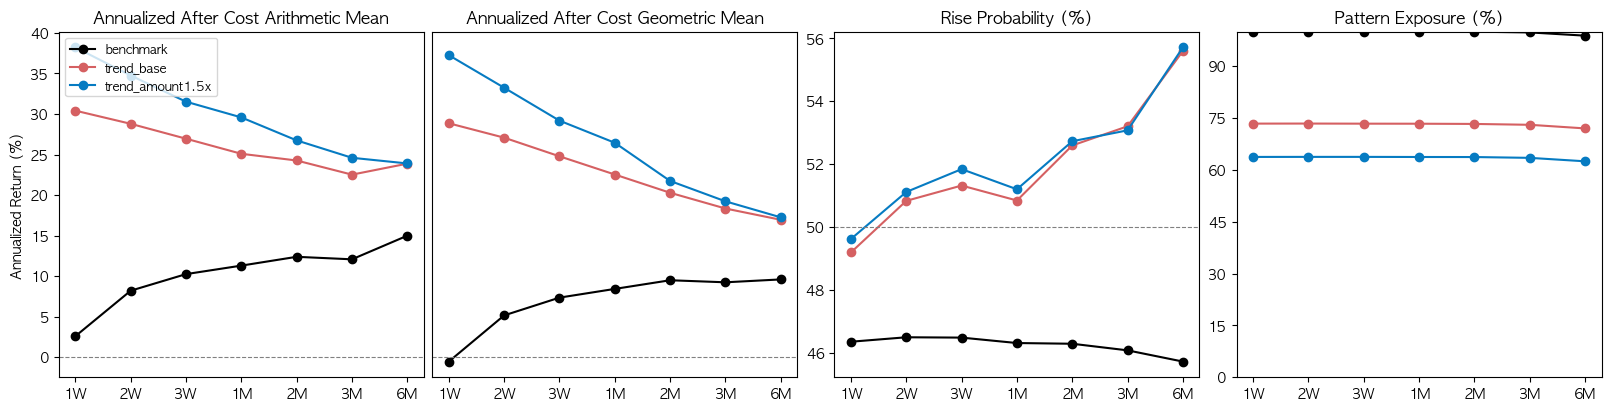

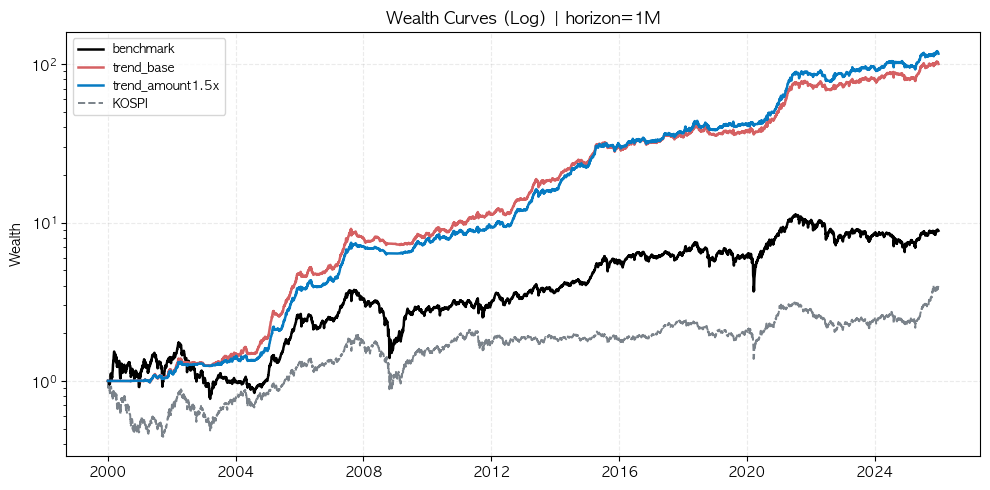

,total_return,final_wealth,cagr,mdd,ann_vol,ir,mean_exposure,cohort_win_rate,payoff_ratio,active_day_ratio,total_fee_paid
pattern,,,,,,,,,,,
benchmark,7.8713,8.8713,0.0876,-0.6290,0.2105,0.4163,0.9983,0.5643,1.1274,1.0000,3.2896
trend_base,99.2167,100.2167,0.1940,-0.2097,0.1045,1.8558,0.7335,0.5655,1.5630,0.9683,17.3472
trend_amount1.5x,115.3206,116.3206,0.2008,-0.1559,0.1033,1.9439,0.6388,0.5540,1.7024,0.9476,17.1230


In [3]:
bb = Bollinger(name="볼린저돌파").on(
    trigger="breakout_up",
    breakout_cooldown_days=3,
    bandwidth_max=0.05,
)
high52w = High(name="52주 고가").on(window=240, threshold=0.90, stay_days=1)
uptrend = Trending(name="이평상향").on(trigger="ma_trend_up", window=200)
mfi_high = MFI(name="MFI상승").on(trigger="above", threshold=50)
amount15 = AmountSurge(name="amount1.5x").on(window=20, threshold=1.5)

base = (bb + high52w + uptrend + mfi_high).named("trend_base")
best = (bb + high52w + uptrend + mfi_high + amount15).named("trend_amount1.5x")

stats = bt.analyze(base, best)
stats.plot(annualized=True)
bt.plot_wealth_curves(target_horizon="1M", trade_price_mode="당일종가", show_kospi=True)